Authors, copyright and license
-----------------------------

Authors: Lars Arneborg, Linn Carlstedt, Nathan Grivault

Copyright 2025 
- CSC – IT Center for Science (CSC), Danish Meteorological Institute (DMI),
- Finnish Meteorological Institute (FMI), 
- Norwegian Meteorological Institute (MetNo),
- Swedish Meteorological and Hydrological Institute (SMHI), 
- Tallinn University of Technology (TalTech)

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

License: Apache-2.0

In [1]:
import numpy as np
import xarray as xr
import earthkit.data
import earthkit.plots
import earthkit.regrid
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
request = {
     'activity': 'ScenarioMIP',
     'class': 'd1',
     'dataset': 'climate-dt',
     'date': '20200101/20200102',
     'experiment': 'SSP3-7.0',
     'expver': '0001',
     'generation': '1',
     'levtype': 'o3d',
     'levelist': '1', 
     'model': 'ICON', #IFS-NEMO
     'param': '263500',
     'realization': '1',
     'resolution': 'high',
     'stream': 'clte',
     'time': '0000', # '0100/0200/0300/0400/0500/0600'
     'type': 'fc'
 }

In [25]:
data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)

2025-01-20 14:56:41 - INFO - Key read from /home/ubuntu/.polytopeapirc
2025-01-20 14:56:41 - INFO - Sending request...
{'request': 'activity: ScenarioMIP\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20200101/20200102\n'
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            "generation: '1'\n"
            "levelist: '1'\n"
            'levtype: o3d\n'
            'model: ICON\n'
            "param: '263501'\n"
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2025-01-20 14:56:41 - INFO - Polytope user key found in session cache for user ubuntu
2025-01-20 14:56:41 - INFO - Request accepted. Please poll ./f5ea1e78-ef81-473c-b4df-3d800268bc4a for status
2025-01-20 14:56:41 - INFO - Polytope user key found in session cache for user ubuntu
2025-01-20 14:56:41 - INFO - Checking request status (./f5ea1e78-ef81-

HTTPResponseError: Polytope error
Situation: trying to download data
Description: HTTP CLIENT ERROR (400)
URL: https://polytope.lumi.apps.dte.destination-earth.eu:443/api/v1/requests/./f5ea1e78-ef81-473c-b4df-3d800268bc4a
HTTP method: GET
Request header/body contents:
{'headers': {'Authorization': 'Bearer **********6dTg'}, 'json': None}
Expected responses: 200, 202
Received response: CLIENT ERROR (400)
Details:
Request failed with error:
Failed to finalize request: [<class 'ValueError'>] No data retrieved
No data retrieved

In [ ]:
out_grid = {"grid": [0.1,0.1]}
r = earthkit.regrid.interpolate(data, out_grid=out_grid, method="linear")
d = r.data()
lat = d[0]
lon = d[1]
vals = d[2:]
lat.shape, lon.shape, vals.shape

In [ ]:
ds = r.to_xarray()
ds

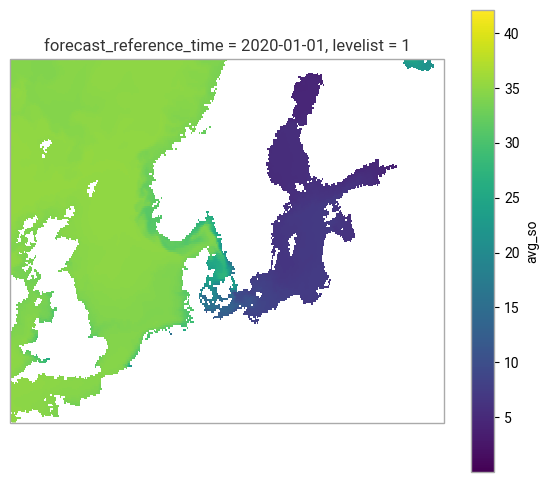

In [18]:
central_latitude = 58
central_longitude = 8
false_easting = 60
false_northing = 60
extend = [-5, 28, 48, 66]

coastlines = cfeature.GSHHSFeature(scale='high',linewidths=0.25, edgecolor='k', facecolor='0.8')
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.Stereographic(central_latitude=central_latitude, central_longitude=central_longitude, false_easting=false_easting, false_northing=false_northing)},)
p = ds["avg_so"].isel(levelist=0,forecast_reference_time=0).plot(
    x='longitude',
    y='latitude',
    transform=ccrs.PlateCarree(),
    #cbar_kwargs={'orientation': 'vertical', 'label': label},
    cmap=None, 
    norm=None,
    )
ax.set_extent(extend)

In [5]:
# Try some processing by plotting the mean SST over the Baltic for 1 year
import pandas
from datetime import date, timedelta
sdate = '20200101'
edate = '20201231'
date_ranges = pandas.date_range(sdate, edate,freq='d')
date_str = ""
for f in date_ranges: 
    date_str = date_str + f.strftime("%Y%m%d") + '/'
date_str = date_str[:-1]
#print(date_str)

In [71]:

request = {
     'activity': 'ScenarioMIP',
     'class': 'd1',
     'dataset': 'climate-dt',
     'date': '20200101/20200102/20200103/20200104/20200105/20200106/20200107/20200108/20200109/20200110/20200111/20200112/20200113/20200114/20200115/20200116/20200117/20200118/20200119/20200120/20200121/20200122/20200123/20200124/20200125/20200126/20200127/20200128/20200129/20200130/20200131/20200201',
     'experiment': 'SSP3-7.0',
     'expver': '0001',
     'generation': '1',
     'levtype': 'o3d',
     'levelist': '1/48', 
     'model': 'IFS-NEMO',
     'param': '263500',
     'realization': '1',
     'resolution': 'high',
     'stream': 'clte',
     'time': '0000', # '0100/0200/0300/0400/0500/0600'
     'type': 'fc'
 }
data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)

2025-01-20 16:02:48 - INFO - Key read from /home/ubuntu/.polytopeapirc
2025-01-20 16:02:48 - INFO - Sending request...
{'request': 'activity: ScenarioMIP\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: '
            '20200101/20200102/20200103/20200104/20200105/20200106/20200107/20200108/20200109/20200110/20200111/20200112/20200113/20200114/20200115/20200116/20200117/20200118/20200119/20200120/20200121/20200122/20200123/20200124/20200125/20200126/20200127/20200128/20200129/20200130/20200131/20200201\n'
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            "generation: '1'\n"
            'levelist: 1/48\n'
            'levtype: o3d\n'
            'model: IFS-NEMO\n'
            "param: '263500'\n"
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2025-01-20 16:02:48 - INFO - Polytope user key found in sessi

In [72]:
out_grid = {"grid": [0.1,0.1]}
r = earthkit.regrid.interpolate(data, out_grid=out_grid, method="linear")
ds = r.to_xarray()
ds

<xarray.Dataset> Size: 3GB
Dimensions:                  (forecast_reference_time: 32, levelist: 2,
                              latitude: 1801, longitude: 3600)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 256B 20...
  * levelist                 (levelist) int64 16B 1 48
  * latitude                 (latitude) float64 14kB 90.0 89.9 ... -89.9 -90.0
  * longitude                (longitude) float64 29kB 0.0 0.1 ... 359.8 359.9
Data variables:
    avg_so                   (forecast_reference_time, levelist, latitude, longitude) float64 3GB ...
Attributes: (12/13)
    param:          avg_so
    standard_name:  unknown
    long_name:      Time-mean sea water practical salinity
    paramId:        263500
    class:          d1
    stream:         clte
    ...             ...
    type:           fc
    expver:         0001
    date:           20200101
    time:           0
    Conventions:    CF-1.8
    institution:    ECMWF

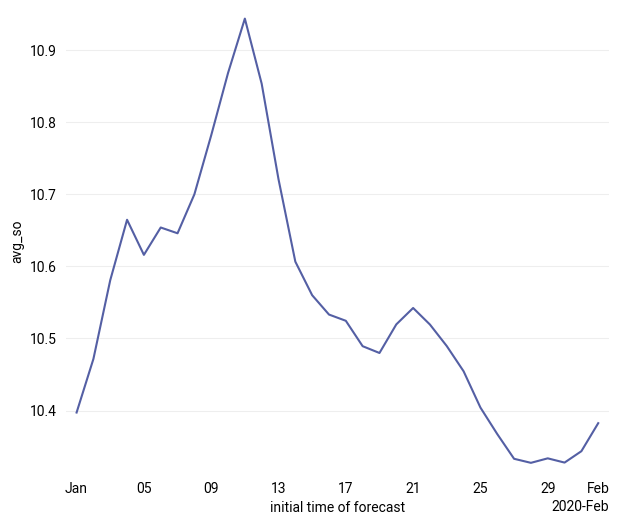

In [68]:
fig, ax = plt.subplots()
p = ds["avg_so"].where(ds["avg_so"] != 0).sel(longitude=slice(9, 31.7), latitude=slice(67, 50)).mean('latitude').mean('longitude').plot(
    x='forecast_reference_time',
    hue='levelist',
    )

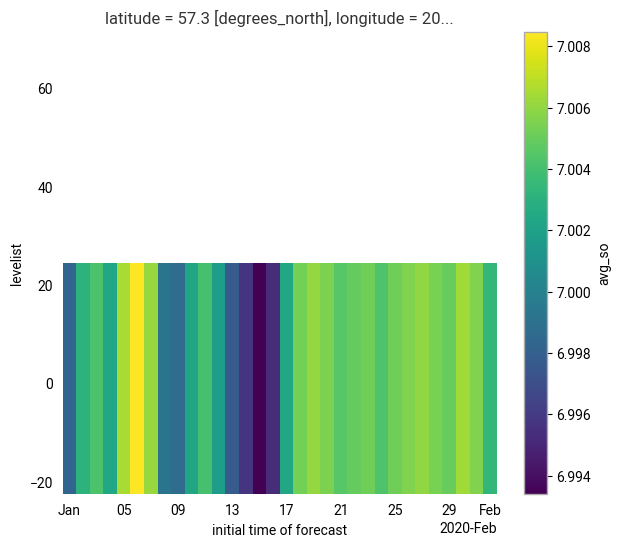

In [73]:
# BY15
p = ds["avg_so"].sel(longitude=20.0500, latitude=57.3333, method="nearest").plot(
    x='forecast_reference_time',
    y='levelist',
)